<hr>

# 🤖 MACHINE LEARNING 🤖

<style>
h1 {
    text-align: center;
    color: hotpink;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<hr>

In [110]:
!pip install xgboost

In [111]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score  
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import numpy as np
from imblearn.over_sampling import SMOTE


In [112]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test  = pd.read_csv("../data/processed/y_test.csv").values.ravel()

# 1. KNearest Neighbours model

## Fitting and prediction

In [113]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train) #fit the model to the training data
pred = knn.predict(X_test) #make predictions on the test set using the fitted model

## Results 

### Accuracy

In [114]:
knn.score(X_test, y_test)

0.8398215733982157

### Classification Report

In [115]:
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))


[[1952  132]
 [ 263  119]]
              precision    recall  f1-score   support

       False       0.88      0.94      0.91      2084
        True       0.47      0.31      0.38       382

    accuracy                           0.84      2466
   macro avg       0.68      0.62      0.64      2466
weighted avg       0.82      0.84      0.83      2466



- 288 actual buyers were predicted as non-buyers
- Only 125 buyers were correctly predicted
- Hence the precision and recall rate for minority class, TRUE, is very low.

### ROC AUC

In [116]:
# Get probability of positive / minority class (class = 1)
y_train_proba_knn = knn.predict_proba(X_train)[:, 1]
y_test_proba_knn  = knn.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc_train_knn = roc_auc_score(y_train, y_train_proba_knn)
roc_auc_test_knn  = roc_auc_score(y_test, y_test_proba_knn)

print("ROC AUC - Train:", roc_auc_train_knn)
print("ROC AUC - Test :", roc_auc_test_knn)

ROC AUC - Train: 0.957234315755654
ROC AUC - Test : 0.702674201847032


### PR AUC

In [117]:
# PR-AUC
pr_auc_train_knn = average_precision_score(y_train, y_train_proba_knn)
pr_auc_test_knn  = average_precision_score(y_test, y_test_proba_knn)

print("PR AUC  - Train:", pr_auc_train_knn)
print("PR AUC  - Test :", pr_auc_test_knn)

PR AUC  - Train: 0.741136084156167
PR AUC  - Test : 0.3316208873564853


- The train and test AUC's have a huge difference.
- The model is memorising than predicting.

# 2. Logistic Regression (class weight balanced)

## Fitting and prediction

In [118]:
# Initialize model
lr= LogisticRegression(class_weight='balanced',max_iter=5000)

# Train
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Evaluation 

### Classification Report

In [119]:
# Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1818  266]
 [  99  283]]
              precision    recall  f1-score   support

       False       0.95      0.87      0.91      2084
        True       0.52      0.74      0.61       382

    accuracy                           0.85      2466
   macro avg       0.73      0.81      0.76      2466
weighted avg       0.88      0.85      0.86      2466



### ROC AUC

In [120]:
# predicted probablities
# Probability of positive class (Revenue = True)
y_train_proba = lr.predict_proba(X_train)[:, 1]
y_test_proba  = lr.predict_proba(X_test)[:, 1]

In [121]:
roc_auc_train = roc_auc_score(y_train, y_train_proba)
roc_auc_test  = roc_auc_score(y_test, y_test_proba)

print("ROC AUC - Train:", roc_auc_train)
print("ROC AUC - Test :", roc_auc_test)

ROC AUC - Train: 0.913818667836968
ROC AUC - Test : 0.8959951663635176


### PR AUC

In [122]:
pr_auc_train = average_precision_score(y_train, y_train_proba)
pr_auc_test  = average_precision_score(y_test, y_test_proba)

print("PR AUC  - Train:", pr_auc_train)
print("PR AUC  - Test :", pr_auc_test)

PR AUC  - Train: 0.6632139892484967
PR AUC  - Test : 0.6222199615774222


- PR AUC of 0.66 is quite decent for a dataset with 15% positive class, denotes a good separation power

# 3. Random Forest

## Fitting and prediction

In [123]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [124]:
y_pred_rf = rf.predict(X_test)

# Probabilities (for AUC)
y_train_proba_rf = rf.predict_proba(X_train)[:, 1]
y_test_proba_rf  = rf.predict_proba(X_test)[:, 1]

## Evaluation 

### Accuracy

In [125]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy_rf)


Accuracy: 0.8961881589618816


### Classification Report

In [126]:
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[2030   54]
 [ 202  180]]
              precision    recall  f1-score   support

       False       0.91      0.97      0.94      2084
        True       0.77      0.47      0.58       382

    accuracy                           0.90      2466
   macro avg       0.84      0.72      0.76      2466
weighted avg       0.89      0.90      0.89      2466



### ROC AUC

In [127]:
roc_train_rf = roc_auc_score(y_train, y_train_proba_rf)
roc_test_rf = roc_auc_score(y_test, y_test_proba_rf)
print("ROC AUC (Train):", roc_train_rf)
print("ROC AUC (Test):", roc_test_rf)

ROC AUC (Train): 1.0
ROC AUC (Test): 0.9197783410879198


### PR AUC

In [128]:
pr_train_rf = average_precision_score(y_train, y_train_proba_rf)
pr_test_rf = average_precision_score(y_test, y_test_proba_rf)
print("PR AUC (Train):", pr_train_rf)
print("PR AUC (Test):", pr_test_rf)

PR AUC (Train): 1.0
PR AUC (Test): 0.721152704621869


- Random Forest model is overfitting but the test performance and PR AUC is higher

### PR curve 

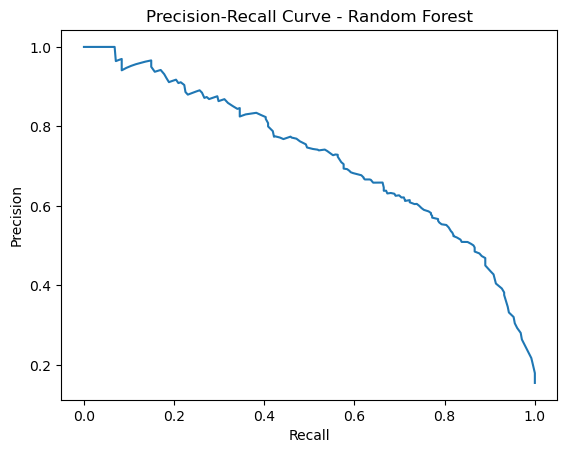

In [129]:
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba_rf)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest")
plt.show()

- X-Axis - **Recall** - How many actual buyers does the model catch?
- Y-Axis - **Precision** - How accurate the buyer predictions were?

- Very high precision at low recall --> targeting top few high probability users, they all convert. This can be used for expensive discounts and when we have limited budget campaign since accuracy / precision is high. 

- At high recall, the precision drops --> so if the model tries to catch all buyers, we also target many non-buyers (low precision / accuracy)

### Feature importance

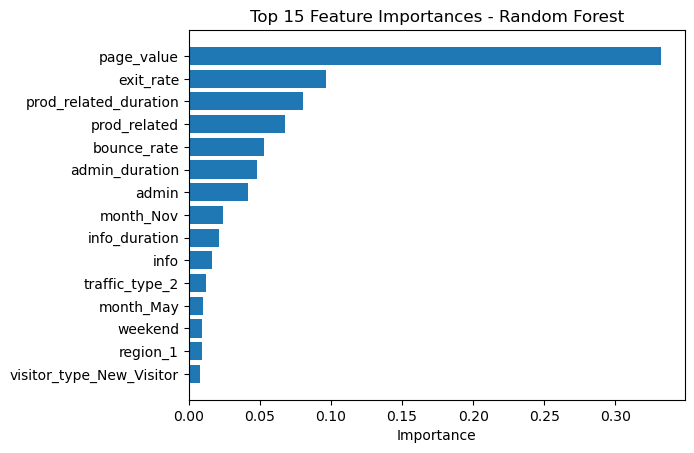

In [130]:
# Get feature importance
importances = rf.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

# Sort descending
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Plot top 15
plt.figure()
plt.barh(feature_importance["Feature"][:15], feature_importance["Importance"][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()

- High-importance features such as Page Value and Exit Rate are strong behavioral signals of purchase intent, but manipulating these need not affect conversions necessarily. 
- Feature importance != Causality

# 4. XGBoost model

## Fitting and Prediction

In [131]:
# Calculate imbalance ratio
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
scale_pos_weight = neg / pos

xgb = XGBClassifier(
    n_estimators=300, #learning rate (0.05, dataset is ~12k rows)
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [16:04:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [132]:
y_pred_xgb = xgb.predict(X_test)

y_train_proba_xgb = xgb.predict_proba(X_train)[:, 1]
y_test_proba_xgb  = xgb.predict_proba(X_test)[:, 1]

## Evaluation

### Accuracy

In [133]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("Accuracy (Test):", accuracy_xgb)

Accuracy (Test): 0.8645579886455799


### Classification Report

In [134]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_xgb = xgb.predict(X_test)

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

[[1819  265]
 [  69  313]]
              precision    recall  f1-score   support

       False       0.96      0.87      0.92      2084
        True       0.54      0.82      0.65       382

    accuracy                           0.86      2466
   macro avg       0.75      0.85      0.78      2466
weighted avg       0.90      0.86      0.88      2466



### ROC AUC

In [135]:
y_train_proba_xgb = xgb.predict_proba(X_train)[:, 1]
y_test_proba_xgb  = xgb.predict_proba(X_test)[:, 1]

roc_train_xgb = roc_auc_score(y_train, y_train_proba_xgb)
roc_test_xgb  = roc_auc_score(y_test, y_test_proba_xgb)

print("ROC AUC (Train):", roc_train_xgb)
print("ROC AUC (Test):", roc_test_xgb)

ROC AUC (Train): 0.9694664041871808
ROC AUC (Test): 0.929172403050919


### PR AUC

In [136]:
pr_train_xgb = average_precision_score(y_train, y_train_proba_xgb)
pr_test_xgb  = average_precision_score(y_test, y_test_proba_xgb)

print("PR AUC (Train):", pr_train_xgb)
print("PR AUC (Test):", pr_test_xgb)

PR AUC (Train): 0.8598049116064888
PR AUC (Test): 0.74208293833551


# Comparison of metrics

In [137]:
# Get reports as dictionary
knn_report = classification_report(y_test, pred, output_dict=True)
log_report = classification_report(y_test, y_pred, output_dict=True)
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)
xgb_report = classification_report(y_test, y_pred_xgb, output_dict=True)

# Create comparison dataframe
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision_TRUE",
        "Recall_TRUE",
        "F1_TRUE",
        "Macro_F1",
        "Weighted_F1",
        "ROC AUC - Train",
        "ROC AUC - Test",
        "PR AUC - Train",
        "PR AUC - Test",
    ],
    "KNN": [
        knn_report["accuracy"],
        knn_report["True"]["precision"],
        knn_report["True"]["recall"],
        knn_report["True"]["f1-score"],
        knn_report["macro avg"]["f1-score"],
        knn_report["weighted avg"]["f1-score"],
        roc_auc_train_knn,
        roc_auc_test_knn,
        pr_auc_train_knn,
        pr_auc_test_knn,
    ],
    "Logistic Regression": [
        log_report["accuracy"],
        log_report["True"]["precision"],
        log_report["True"]["recall"],
        log_report["True"]["f1-score"],
        log_report["macro avg"]["f1-score"],
        log_report["weighted avg"]["f1-score"],
        roc_auc_train,
        roc_auc_test,
        pr_auc_train,
        pr_auc_test,
    ],
    "Random Forest": [
        rf_report["accuracy"],
        rf_report["True"]["precision"],
        rf_report["True"]["recall"],
        rf_report["True"]["f1-score"],
        rf_report["macro avg"]["f1-score"],
        rf_report["weighted avg"]["f1-score"],
        roc_train_rf,
        roc_test_rf,
        pr_train_rf,
        pr_test_rf,
    ],
    "XGBoost": [
        accuracy_xgb,
        xgb_report["True"]["precision"],
        xgb_report["True"]["recall"],
        xgb_report["True"]["f1-score"],
        xgb_report["macro avg"]["f1-score"],
        xgb_report["weighted avg"]["f1-score"],
        roc_train_xgb,
        roc_test_xgb,
        pr_train_xgb,
        pr_test_xgb,
     ],        
})

comparison


,Metric,KNN,Logistic Regression,Random Forest,XGBoost
0,Accuracy,0.839822,0.851987,0.896188,0.864558
1,Precision_TRUE,0.474104,0.515483,0.769231,0.541522
2,Recall_TRUE,0.311518,0.740838,0.471204,0.819372
3,F1_TRUE,0.375987,0.607948,0.584416,0.652083
4,Macro_F1,0.642053,0.758361,0.762551,0.783997
5,Weighted_F1,0.825688,0.862173,0.885497,0.875043
6,ROC AUC - Train,0.957234,0.913819,1.000000,0.969466
7,ROC AUC - Test,0.702674,0.895995,0.919778,0.929172
8,PR AUC - Train,0.741136,0.663214,1.000000,0.859805
9,PR AUC - Test,0.331621,0.622220,0.721153,0.742083


# Model Optimisation

## Probability Disribution Plot - XGBoost

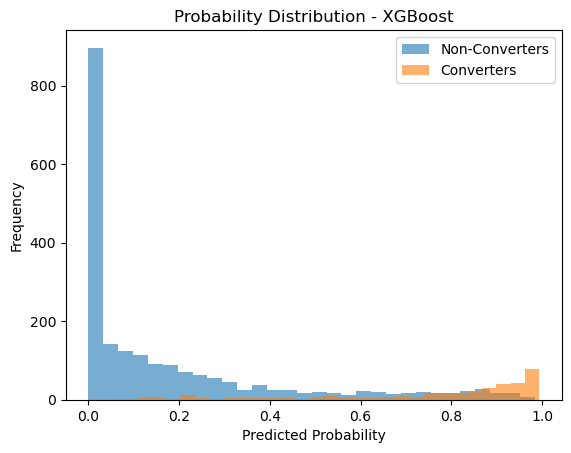

In [138]:
# Separate probabilities by class
probs_true = y_test_proba_xgb[y_test == 1]
probs_false = y_test_proba_xgb[y_test == 0]

plt.figure()
plt.hist(probs_false, bins=30, alpha=0.6, label="Non-Converters")
plt.hist(probs_true, bins=30, alpha=0.6, label="Converters")

plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Probability Distribution - XGBoost")
plt.legend()
plt.show()

- Many non-converters are near 0 and converters are near 1, which is good.

- There is also some overlap ~ 0.2 - 0.6, makes sense because perfect separation is unrealistic.

### New Probability Threshold - 1

In [139]:
threshold = 0.35

y_pred_xgb_new = (y_test_proba_xgb >= threshold).astype(int)

## Evaluation

### Accuracy

In [140]:
accuracy_xgb_new = accuracy_score(y_test, y_pred_xgb_new)
print("Accuracy (Test):", accuracy_xgb_new)

Accuracy (Test): 0.8284671532846716


### Classification Report

In [141]:
print("Confusion Matrix (Threshold = 0.35)")
print(confusion_matrix(y_test, y_pred_xgb_new))

print("\nClassification Report (Threshold = 0.35)")
print(classification_report(y_test, y_pred_xgb_new))

Confusion Matrix (Threshold = 0.35)
[[1707  377]
 [  46  336]]

Classification Report (Threshold = 0.35)
              precision    recall  f1-score   support

       False       0.97      0.82      0.89      2084
        True       0.47      0.88      0.61       382

    accuracy                           0.83      2466
   macro avg       0.72      0.85      0.75      2466
weighted avg       0.90      0.83      0.85      2466



### New Probability Threshold - 2

In [142]:
threshold = 0.25

y_pred_xgb_new2 = (y_test_proba_xgb >= threshold).astype(int)

## Evaluation

### Accuracy

In [143]:
accuracy_xgb_new2 = accuracy_score(y_test, y_pred_xgb_new2)
print("Accuracy (Test):", accuracy_xgb_new2)

Accuracy (Test): 0.772911597729116


### Classification Report

In [144]:
print("Confusion Matrix (Threshold = 0.25)")
print(confusion_matrix(y_test, y_pred_xgb_new2))

print("\nClassification Report (Threshold = 0.25)")
print(classification_report(y_test, y_pred_xgb_new2))

Confusion Matrix (Threshold = 0.25)
[[1560  524]
 [  36  346]]

Classification Report (Threshold = 0.25)
              precision    recall  f1-score   support

       False       0.98      0.75      0.85      2084
        True       0.40      0.91      0.55       382

    accuracy                           0.77      2466
   macro avg       0.69      0.83      0.70      2466
weighted avg       0.89      0.77      0.80      2466



# Fine Tuning / Feature Importance

## Experiment - 1 - Check if 'page_value' column is target leaking

In [145]:
X_train_pv = X_train[["page_value"]]
X_test_pv  = X_test[["page_value"]]

In [146]:
#Logistic Regression
lr_pv = LogisticRegression(class_weight="balanced", max_iter=5000)
lr_pv.fit(X_train_pv, y_train)

y_pred_pv = lr_pv.predict(X_test_pv)

y_train_proba_pv = lr_pv.predict_proba(X_train_pv)[:, 1]
y_test_proba_pv  = lr_pv.predict_proba(X_test_pv)[:, 1]

### Evaluation

In [147]:
print("Accuracy:", accuracy_score(y_test, y_pred_pv))
print(confusion_matrix(y_test, y_pred_pv))
print(classification_report(y_test, y_pred_pv))

Accuracy: 0.8791565287915653
[[1930  154]
 [ 144  238]]
              precision    recall  f1-score   support

       False       0.93      0.93      0.93      2084
        True       0.61      0.62      0.61       382

    accuracy                           0.88      2466
   macro avg       0.77      0.77      0.77      2466
weighted avg       0.88      0.88      0.88      2466



In [148]:
roc_train_pv = roc_auc_score(y_train, y_train_proba_pv)
roc_test_pv  = roc_auc_score(y_test, y_test_proba_pv)

print("ROC AUC (Train):", roc_train_pv)
print("ROC AUC (Test):", roc_test_pv)

ROC AUC (Train): 0.8673157317616421
ROC AUC (Test): 0.8472405060747054


In [149]:
from sklearn.metrics import average_precision_score

pr_train_pv = average_precision_score(y_train, y_train_proba_pv)
pr_test_pv  = average_precision_score(y_test, y_test_proba_pv)

print("PR AUC (Train):", pr_train_pv)
print("PR AUC (Test):", pr_test_pv)

PR AUC (Train): 0.6301941567217905
PR AUC (Test): 0.5828457249580601


- Does not indicate a leak / target encoding since the AUC values are not too closer to 1

## Experiment - 2 - Drop page_value column

In [150]:
X_train_no_pv = X_train.drop(columns=["page_value"])
X_test_no_pv  = X_test.drop(columns=["page_value"])

### Random Forest

In [151]:
rf_no_pv = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_no_pv.fit(X_train_no_pv, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [152]:
y_pred_rf_no_pv = rf_no_pv.predict(X_test_no_pv)

y_train_proba_rf_no_pv = rf_no_pv.predict_proba(X_train_no_pv)[:, 1]
y_test_proba_rf_no_pv  = rf_no_pv.predict_proba(X_test_no_pv)[:, 1]

## Evaluation 

### Accuracy

In [153]:
accuracy_rf = accuracy_score(y_test, y_pred_rf_no_pv)
print("Accuracy:", accuracy_rf)


Accuracy: 0.8487429034874291


### Classification Report

In [154]:
print(confusion_matrix(y_test, y_pred_rf_no_pv))
print(classification_report(y_test, y_pred_rf_no_pv))

[[2057   27]
 [ 346   36]]
              precision    recall  f1-score   support

       False       0.86      0.99      0.92      2084
        True       0.57      0.09      0.16       382

    accuracy                           0.85      2466
   macro avg       0.71      0.54      0.54      2466
weighted avg       0.81      0.85      0.80      2466



### ROC AUC

In [155]:
print("ROC AUC - Train:", roc_auc_score(y_train, y_train_proba_rf_no_pv))
print("ROC AUC - Test :", roc_auc_score(y_test, y_test_proba_rf_no_pv))

ROC AUC - Train: 1.0
ROC AUC - Test : 0.7607927766779552


### PR AUC

In [156]:
print("PR AUC - Train:", average_precision_score(y_train, y_train_proba_rf_no_pv))
print("PR AUC - Test :", average_precision_score(y_test, y_test_proba_rf_no_pv))

PR AUC - Train: 1.0
PR AUC - Test : 0.35993677636017996


## Experiment - 3 - Dropping bottom 25% features, importance wise

### Random Forest

In [157]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [158]:
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
)

low_features = importances.sort_values().head(int(len(importances)*0.25)).index # drop bottom 25% features

X_train_drop = X_train.drop(columns=low_features)
X_test_drop  = X_test.drop(columns=low_features)

print("Dropped", len(low_features), "features")

Dropped 18 features


In [159]:
rf_drop = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_drop.fit(X_train_drop, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [160]:
y_pred_rf_drop = rf_drop.predict(X_test_drop)

y_train_proba_rf_drop = rf_drop.predict_proba(X_train_drop)[:, 1]
y_test_proba_rf_drop  = rf_drop.predict_proba(X_test_drop)[:, 1]

## Evaluation 

### Accuracy

In [161]:
accuracy_rf = accuracy_score(y_test, y_pred_rf_drop)
print("Accuracy:", accuracy_rf)


Accuracy: 0.8982157339821574


### Classification Report

In [162]:
print(confusion_matrix(y_test, y_pred_rf_drop))
print(classification_report(y_test, y_pred_rf_drop))

[[2029   55]
 [ 196  186]]
              precision    recall  f1-score   support

       False       0.91      0.97      0.94      2084
        True       0.77      0.49      0.60       382

    accuracy                           0.90      2466
   macro avg       0.84      0.73      0.77      2466
weighted avg       0.89      0.90      0.89      2466



### ROC AUC

In [163]:
print("ROC AUC - Train:", roc_auc_score(y_train, y_train_proba_rf_drop))
print("ROC AUC - Test :", roc_auc_score(y_test, y_test_proba_rf_drop))

ROC AUC - Train: 1.0
ROC AUC - Test : 0.920430279064626


### PR AUC

In [164]:
print("PR AUC - Train:", average_precision_score(y_train, y_train_proba_rf_drop))
print("PR AUC - Test :", average_precision_score(y_test, y_test_proba_rf_drop))

PR AUC - Train: 1.0
PR AUC - Test : 0.724627730135415


## Experiment - 4 - Hyperparameter tuning

### Random Forest - to reduce overfitting

In [165]:
param_grid = {
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

grid_rf = GridSearchCV(
    rf,
    param_grid,
    scoring="average_precision",   #for imbalance
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best parameters:", grid_rf.best_params_)
print("Best CV PR AUC:", grid_rf.best_score_)

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 10}
Best CV PR AUC: 0.7409900676147279


In [166]:
best_rf = grid_rf.best_estimator_

## Evaluation 

In [167]:
# Predictions
y_pred_best_rf = best_rf.predict(X_test)
y_train_proba_best_rf = best_rf.predict_proba(X_train)[:, 1]
y_test_proba_best_rf  = best_rf.predict_proba(X_test)[:, 1]

# Accuracy + report
print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print(confusion_matrix(y_test, y_pred_best_rf))
print(classification_report(y_test, y_pred_best_rf))

# ROC AUC
print("ROC AUC (Train):", roc_auc_score(y_train, y_train_proba_best_rf))
print("ROC AUC (Test):", roc_auc_score(y_test, y_test_proba_best_rf))

# PR AUC
print("PR AUC (Train):", average_precision_score(y_train, y_train_proba_best_rf))
print("PR AUC (Test):", average_precision_score(y_test, y_test_proba_best_rf))

Accuracy: 0.8852392538523925
[[1905  179]
 [ 104  278]]
              precision    recall  f1-score   support

       False       0.95      0.91      0.93      2084
        True       0.61      0.73      0.66       382

    accuracy                           0.89      2466
   macro avg       0.78      0.82      0.80      2466
weighted avg       0.90      0.89      0.89      2466

ROC AUC (Train): 0.9890284245540715
ROC AUC (Test): 0.920732381344776
PR AUC (Train): 0.9480503994513444
PR AUC (Test): 0.7138114923069208


## Experiment - 5 - SMOTE

In [168]:
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())

Before SMOTE:
False    8338
True     1526
Name: count, dtype: int64

After SMOTE:
False    8338
True     8338
Name: count, dtype: int64


### Logistic Regression with SMOTE and without class weight balanced

In [169]:
lr_sm = LogisticRegression(max_iter=5000)

lr_sm.fit(X_train_sm, y_train_sm)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5000)

In [170]:
y_pred_lr_sm = lr_sm.predict(X_test)

y_train_proba_lr_sm = lr_sm.predict_proba(X_train_sm)[:, 1]
y_test_proba_lr_sm  = lr_sm.predict_proba(X_test)[:, 1]

### Evaluation 

In [171]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr_sm))
print(confusion_matrix(y_test, y_pred_lr_sm))
print(classification_report(y_test, y_pred_lr_sm))

print("ROC AUC - Train:", roc_auc_score(y_train_sm, y_train_proba_lr_sm))
print("ROC AUC - Test :", roc_auc_score(y_test, y_test_proba_lr_sm))

print("PR AUC - Train:", average_precision_score(y_train_sm, y_train_proba_lr_sm))
print("PR AUC - Test :", average_precision_score(y_test, y_test_proba_lr_sm))

Accuracy: 0.8552311435523114
[[1833  251]
 [ 106  276]]
              precision    recall  f1-score   support

       False       0.95      0.88      0.91      2084
        True       0.52      0.72      0.61       382

    accuracy                           0.86      2466
   macro avg       0.73      0.80      0.76      2466
weighted avg       0.88      0.86      0.86      2466

ROC AUC - Train: 0.9275910167686762
ROC AUC - Test : 0.88954989900614
PR AUC - Train: 0.9116442276854698
PR AUC - Test : 0.6204483883398519


## Experiment - 6 - Scale POS weight  - XGBoost

In [172]:
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
base_spw = neg / pos

print("neg:", neg, "pos:", pos, "base scale_pos_weight:", base_spw)

neg: 8338 pos: 1526 base scale_pos_weight: 5.463958060288335


In [173]:
spw_grid = [3, 4, 5, 5.6, 6, 7, 8]

for spw in spw_grid:
    
    print("\n" + "="*60)
    print(f"scale_pos_weight = {spw}")
    print("="*60)
    
    # Initialize model
    xgb_spw = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,
        random_state=42,
        eval_metric="logloss"
    )

    # Train
    xgb_spw.fit(X_train, y_train)

    # Predictions
    y_pred_test = xgb_spw.predict(X_test)
    y_pred_train = xgb_spw.predict(X_train)

    y_proba_test = xgb_spw.predict_proba(X_test)[:, 1]
    y_proba_train = xgb_spw.predict_proba(X_train)[:, 1]

    # Accuracy
    print("Accuracy (Test):", accuracy_score(y_test, y_pred_test))

    # Confusion Matrix
    print("\nConfusion Matrix (Test):")
    print(confusion_matrix(y_test, y_pred_test))

    # Classification Report
    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_pred_test))

    # ROC AUC
    print("ROC AUC (Train):", roc_auc_score(y_train, y_proba_train))
    print("ROC AUC (Test) :", roc_auc_score(y_test, y_proba_test))

    # PR AUC
    print("PR AUC (Train):", average_precision_score(y_train, y_proba_train))
    print("PR AUC (Test) :", average_precision_score(y_test, y_proba_test))


scale_pos_weight = 3
Accuracy (Test): 0.8819951338199513

Confusion Matrix (Test):
[[1890  194]
 [  97  285]]

Classification Report (Test):
              precision    recall  f1-score   support

       False       0.95      0.91      0.93      2084
        True       0.59      0.75      0.66       382

    accuracy                           0.88      2466
   macro avg       0.77      0.83      0.80      2466
weighted avg       0.90      0.88      0.89      2466

ROC AUC (Train): 0.969234162027849
ROC AUC (Test) : 0.9292741505964164
PR AUC (Train): 0.8657711751232964
PR AUC (Test) : 0.741274321156746

scale_pos_weight = 4
Accuracy (Test): 0.8746958637469586

Confusion Matrix (Test):
[[1859  225]
 [  84  298]]

Classification Report (Test):
              precision    recall  f1-score   support

       False       0.96      0.89      0.92      2084
        True       0.57      0.78      0.66       382

    accuracy                           0.87      2466
   macro avg       0.76      0.

## Fine Tuning - Scale POS weight  of 3 to 4 - XGBoost

In [174]:
spw_grid = [3, 3.25, 3.5, 3.75, 4]

for spw in spw_grid:
    
    print("\n" + "="*60)
    print(f"scale_pos_weight = {spw}")
    print("="*60)
    
    # Initialize model
    xgb_spw = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,
        random_state=42,
        eval_metric="logloss"
    )

    # Train
    xgb_spw.fit(X_train, y_train)

    # Predictions
    y_pred_test = xgb_spw.predict(X_test)
    y_pred_train = xgb_spw.predict(X_train)

    y_proba_test = xgb_spw.predict_proba(X_test)[:, 1]
    y_proba_train = xgb_spw.predict_proba(X_train)[:, 1]

    # Accuracy
    print("Accuracy (Test):", accuracy_score(y_test, y_pred_test))

    # Confusion Matrix
    print("\nConfusion Matrix (Test):")
    print(confusion_matrix(y_test, y_pred_test))

    # Classification Report
    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_pred_test))

    # ROC AUC
    print("ROC AUC (Train):", roc_auc_score(y_train, y_proba_train))
    print("ROC AUC (Test) :", roc_auc_score(y_test, y_proba_test))

    # PR AUC
    print("PR AUC (Train):", average_precision_score(y_train, y_proba_train))
    print("PR AUC (Test) :", average_precision_score(y_test, y_proba_test))


scale_pos_weight = 3
Accuracy (Test): 0.8819951338199513

Confusion Matrix (Test):
[[1890  194]
 [  97  285]]

Classification Report (Test):
              precision    recall  f1-score   support

       False       0.95      0.91      0.93      2084
        True       0.59      0.75      0.66       382

    accuracy                           0.88      2466
   macro avg       0.77      0.83      0.80      2466
weighted avg       0.90      0.88      0.89      2466

ROC AUC (Train): 0.969234162027849
ROC AUC (Test) : 0.9292741505964164
PR AUC (Train): 0.8657711751232964
PR AUC (Test) : 0.741274321156746

scale_pos_weight = 3.25
Accuracy (Test): 0.8799675587996756

Confusion Matrix (Test):
[[1882  202]
 [  94  288]]

Classification Report (Test):
              precision    recall  f1-score   support

       False       0.95      0.90      0.93      2084
        True       0.59      0.75      0.66       382

    accuracy                           0.88      2466
   macro avg       0.77     

- POS 3 gives the highest PR AUC. Let's plot the PR curve for this to find out the threshold.

### PR curve for SPW 3

PR AUC (Test): 0.741274321156746


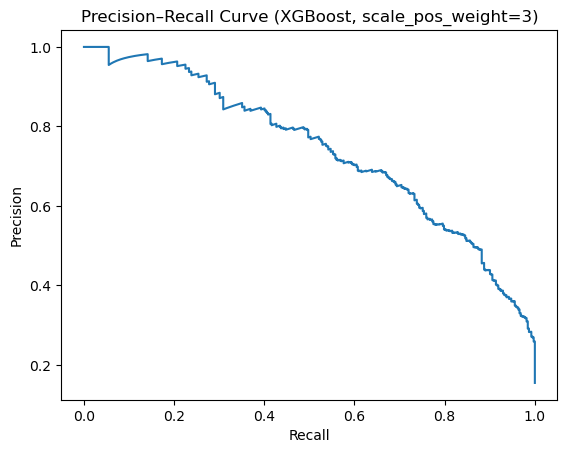

In [175]:
# XGBoost with scale_pos_weight = 3
xgb_spw3 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,
    random_state=42,
    eval_metric="logloss"
)

xgb_spw3.fit(X_train, y_train)

# Predicted probabilities on TEST set
y_test_proba_spw3 = xgb_spw3.predict_proba(X_test)[:, 1]

# Precision-Recall curve points
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba_spw3)

# PR AUC (Average Precision)
pr_auc = average_precision_score(y_test, y_test_proba_spw3)
print("PR AUC (Test):", pr_auc)

# Plot PR curve
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (XGBoost, scale_pos_weight=3)")
plt.show()

### Adding additional features

In [176]:
# -------- FEATURE 1: Total Duration --------
X_train["total_duration"] = (
    X_train["admin_duration"] +
    X_train["info_duration"] +
    X_train["prod_related_duration"]
)

X_test["total_duration"] = (
    X_test["admin_duration"] +
    X_test["info_duration"] +
    X_test["prod_related_duration"]
)

# -------- FEATURE 2: Product Focus --------
X_train["product_focus"] = (
    X_train["prod_related_duration"] /
    (X_train["total_duration"] + 1)
)

X_test["product_focus"] = (
    X_test["prod_related_duration"] /
    (X_test["total_duration"] + 1)
)

# -------- FEATURE 3: Product Depth × Time --------
X_train["prod_depth_time"] = (
    X_train["prod_related"] *
    X_train["prod_related_duration"]
)

X_test["prod_depth_time"] = (
    X_test["prod_related"] *
    X_test["prod_related_duration"]
)

#### Retrain XGBoost with spw = 3

In [177]:
xgb_spw3_new = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,
    random_state=42,
    eval_metric="logloss"
)

xgb_spw3_new.fit(X_train, y_train)

# Probabilities
y_test_proba_new = xgb_spw3_new.predict_proba(X_test)[:, 1]

# Predictions (threshold = 0.5)
y_pred_new = (y_test_proba_new >= 0.5).astype(int)

# PR AUC
pr_auc_new = average_precision_score(y_test, y_test_proba_new)
print("PR AUC (Test):", pr_auc_new)

# Precision, Recall, F1
precision_new = precision_score(y_test, y_pred_new)
recall_new = recall_score(y_test, y_pred_new)
f1_new = f1_score(y_test, y_pred_new)

print("Precision:", precision_new)
print("Recall:", recall_new)
print("F1 Score:", f1_new)

PR AUC (Test): 0.7422670253252333
Precision: 0.609704641350211
Recall: 0.756544502617801
F1 Score: 0.6752336448598131


- Adding new features did not improve PR AUC. The precision has also come down, so model looks saturated at this point

### Probability Threshold

In [178]:
#PR threshold
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba_spw3)

#creating a table of thresholds, precision, and recall
pr_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

pr_df.head(10)

,threshold,precision,recall
0,0.000482,0.154907,1.0
1,0.000576,0.154970,1.0
2,0.000584,0.155032,1.0
3,0.000671,0.155095,1.0
4,0.000715,0.155158,1.0
5,0.000771,0.155221,1.0
6,0.000779,0.155285,1.0
7,0.000866,0.155348,1.0
8,0.000893,0.155411,1.0
9,0.000900,0.155474,1.0


#### PR for recall < 0.90

In [179]:
pr_df[pr_df["recall"] < 0.90].head()

,threshold,precision,recall
1671,0.201598,0.438059,0.897906
1672,0.203464,0.438619,0.897906
1673,0.204151,0.439181,0.897906
1674,0.204211,0.438462,0.895288
1675,0.204325,0.439024,0.895288


#### PR for recall near 0.85

In [180]:
pr_df.iloc[(pr_df["recall"] - 0.85).abs().argsort()[:5]]

,threshold,precision,recall
1819,0.303813,0.511811,0.850785
1820,0.305124,0.512618,0.850785
1821,0.306518,0.511848,0.848168
1822,0.307204,0.512658,0.848168
1823,0.309728,0.513471,0.848168


#### Best F1

In [181]:
pr_df["f1"] = 2 * (pr_df["precision"] * pr_df["recall"]) / (pr_df["precision"] + pr_df["recall"])
pr_df.loc[pr_df["f1"].idxmax()]

threshold    0.576681
precision    0.643192
recall       0.717277
f1           0.678218
Name: 2028, dtype: float64

Business Interpretation:

- Nudges like Discount codes (10–20% off), Cashback offers, Free shipping, Personalized coupon campaigns, limited time deals on price are expensive, so we'll have to strike a balance between the recall and precision

- Recall  = 0.70 means we capture 70% of all converters

- Precision = 0.69 means of customers we target, 69% convert, 31% nudges go to non-converters ~ this means a controlled marketing budget expenditure

## Hyperparameter Tuning

In [182]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, accuracy_score
)

# Base model with spw fixed
xgb_fixed_spw3 = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    tree_method="hist",
    n_jobs=1,
    scale_pos_weight=3
)

# Grid search parameters
param_grid = {
    "n_estimators": [200, 300],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 4, 5],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "gamma": [0, 0.5, 1.0]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=xgb_fixed_spw3,
    param_grid=param_grid,
    scoring="average_precision",  
    cv=cv,
    n_jobs=1,                 
    verbose=1
)

grid.fit(X_train, y_train)

print("\nBest params:", grid.best_params_)
print("Best CV PR AUC:", grid.best_score_)

best_xgb = grid.best_estimator_

# --- Final evaluation on TEST set (same metrics you’ve been using) ---
y_test_proba = best_xgb.predict_proba(X_test)[:, 1]
y_pred = (y_test_proba >= 0.5).astype(int)

print("\nAccuracy (Test):", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix (Test):\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report (Test):\n", classification_report(y_test, y_pred))

print("ROC AUC (Test):", roc_auc_score(y_test, y_test_proba))
print("PR AUC  (Test):", average_precision_score(y_test, y_test_proba))

print("\nPrecision (Test):", precision_score(y_test, y_pred))
print("Recall    (Test):", recall_score(y_test, y_pred))
print("F1        (Test):", f1_score(y_test, y_pred))

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


Exception ignored in: <function ResourceTracker.__del__ at 0x102569bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104abdbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1065e9bc0>
Traceback (most recent call last


Best params: {'colsample_bytree': 1.0, 'gamma': 0.5, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 200, 'subsample': 1.0}
Best CV PR AUC: 0.7480695767951205

Accuracy (Test): 0.8852392538523925

Confusion Matrix (Test):
 [[1893  191]
 [  92  290]]

Classification Report (Test):
               precision    recall  f1-score   support

       False       0.95      0.91      0.93      2084
        True       0.60      0.76      0.67       382

    accuracy                           0.89      2466
   macro avg       0.78      0.83      0.80      2466
weighted avg       0.90      0.89      0.89      2466

ROC AUC (Test): 0.9332636592939475
PR AUC  (Test): 0.752240508989202

Precision (Test): 0.6029106029106029
Recall    (Test): 0.7591623036649214
F1        (Test): 0.6720741599073001


- The manual tuning with spw = 3 and prob threshold at 0.6 gave the best results. After Grid search, the PR AUC has increased from 0.74 to 0.75. But the former model has more precision compared to the hyperparameter tuned model. So former model is my final choice